## **Retail Sales Performance Analysis**

**Problem Statement**

The company wants to analyze its retail sales data to understand revenue trends, profit drivers, regional performance, and the impact of discounts on profitability.

**Objective**

*   Analyze sales performance trends
*   Identify top-performing categories
*   Study regional performance
*   Understand customer segment contribution
*   Analyze shipping performance

**Tools Used**

*   Python (Pandas, Matplotlib, Seaborn)
*   MySQL
*   Power BI














In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [32]:
df.shape

(9994, 21)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [34]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [35]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [38]:
# Changing order date and ship date datatype to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [39]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [41]:
df.duplicated().sum()

np.int64(0)

In [43]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [44]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Shipping Days"].describe()

,Shipping Days
count,9994.000000
mean,3.958175
std,1.747567
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [45]:
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Profit Margin"].describe()

,Profit Margin
count,9994.000000
mean,0.120314
std,0.466754
min,-2.750000
25%,0.075000
50%,0.270000
75%,0.362500
max,0.500000


In [46]:
total_sales = df["Sales"].sum()
round(total_sales,2)

np.float64(2297200.86)

In [47]:
total_profit = df["Profit"].sum()
round(total_profit,2)

np.float64(286397.02)

In [48]:
avg_discount = df["Discount"].mean()
round(avg_discount,2)

np.float64(0.16)

In [49]:
avg_profit_margin = df["Profit Margin"].mean()
round(avg_profit_margin,2)

np.float64(0.12)

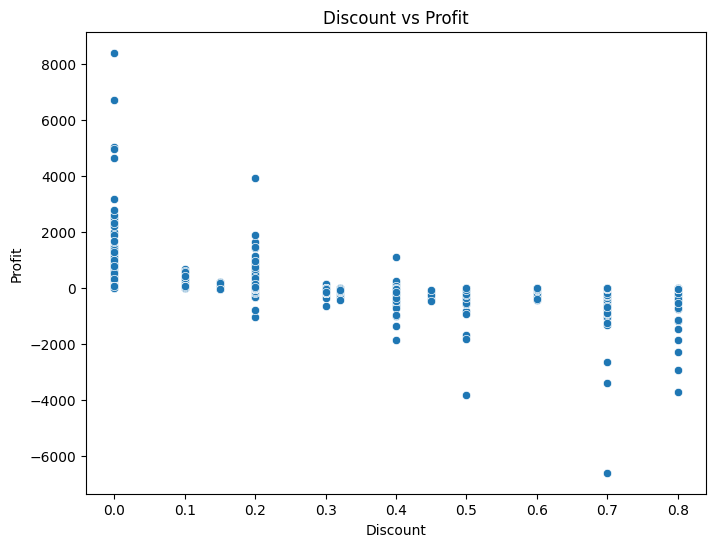

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="Discount",y="Profit")
plt.title("Discount vs Profit")
plt.show()

The scatterplot suggests a negative relationship between discount and profit:

*  Lower discounts are generally associated with higher profits.
*  As discount increases, profit tends to decrease.
*  Several high-discount transactions show negative profit.

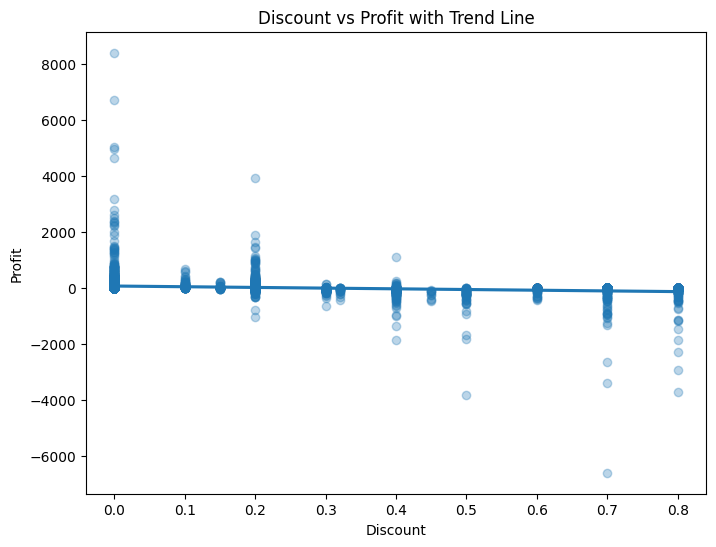

In [52]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="Discount", y="Profit", scatter_kws={'alpha':0.3})
plt.title("Discount vs Profit with Trend Line")
plt.show()

In [51]:
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


The correlation between discount and profit is -0.219, indicating a weak negative relationship. While higher discounts generally reduce profitability, other factors such as product category, region, and cost structure may also influence profit outcomes.

In [55]:
category_analysis = df.groupby("Category")[["Sales","Profit"]].sum()
category_analysis["Profit Margin"] = category_analysis["Profit"] / category_analysis["Sales"]
category_analysis.sort_values(by="Profit",ascending=False)

,Sales,Profit,Profit Margin
Category,,,
Technology,836154.0330,145454.9481,0.173957
Office Supplies,719047.0320,122490.8008,0.170352
Furniture,741999.7953,18451.2728,0.024867


Technology is the most efficient revenue generator and should be prioritized in marketing and inventory planning. Office Supplies provide steady income and act as a stable cash-flow category.

In [56]:
furniture = df[df["Category"]=="Furniture"]
furniture[["Sales","Profit","Discount"]].describe()

,Sales,Profit,Discount
count,2121.000000,2121.000000,2121.000000
mean,349.834887,8.699327,0.173923
std,503.179145,136.049246,0.181547
min,1.892000,-1862.312400,0.000000
25%,47.040000,-12.849000,0.000000
50%,182.220000,7.774800,0.200000
75%,435.168000,33.726600,0.300000
max,4416.174000,1013.127000,0.700000


The Furniture category, despite generating high revenue, exhibits significantly lower profit margins compared to other categories. The higher average discount rate and presence of multiple loss-making transactions suggest that aggressive discounting may be eroding profitability.

In [57]:
tech = df[df["Category"] == "Technology"]

tech[["Sales","Profit","Discount"]].describe()

,Sales,Profit,Discount
count,1847.000000,1847.000000,1847.000000
mean,452.709276,78.752002,0.132323
std,1108.655848,428.816633,0.141575
min,0.990000,-6599.978000,0.000000
25%,68.016000,5.203650,0.000000
50%,166.160000,25.018200,0.200000
75%,448.534000,74.894600,0.200000
max,22638.480000,8399.976000,0.700000


Furniture underperforms in profitability likely due to higher discount exposure and cost structure inefficiencies

In [58]:
subcat_analysis = df.groupby("Sub-Category")[["Sales","Profit"]].sum()
subcat_analysis["Profit Margin"] = subcat_analysis["Profit"] / subcat_analysis["Sales"]
subcat_analysis.sort_values(by="Profit")

,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Supplies,46673.5380,-1189.0995,-0.025477
Fasteners,3024.2800,949.5182,0.313965
Machines,189238.6310,3384.7569,0.017886
Labels,12486.3120,5546.2540,0.444187
Art,27118.7920,6527.7870,0.240711
Envelopes,16476.4020,6964.1767,0.422676
Furnishings,91705.1640,13059.1436,0.142404


Sub-category analysis reveals that Tables and Bookcases are the primary contributors to overall losses, both belonging to the Furniture category. Despite generating revenue, high discount exposure and cost structure inefficiencies may be driving negative profitability. In contrast, Copiers demonstrate strong profit performance, indicating high-margin product positioning within the Technology category.

In [59]:
furniture_sub = df[df["Sub-Category"].isin(["Tables","Bookcases"])]

furniture_sub.groupby("Sub-Category")[["Sales","Profit","Discount"]].mean()

,Sales,Profit,Discount
Sub-Category,,,
Bookcases,503.859633,-15.230509,0.211140
Tables,648.794771,-55.565771,0.261285


In [60]:
region_profit = df.groupby("Region")[["Sales","Profit"]].sum()
region_profit["Profit Margin"] = region_profit["Profit"] / region_profit["Sales"]
region_profit.sort_values(by="Profit")

,Sales,Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,0.079216
South,391721.9050,46749.4303,0.119343
East,678781.2400,91522.7800,0.134834
West,725457.8245,108418.4489,0.149448


In [62]:
df.groupby("Region")[["Sales","Profit","Profit Margin","Discount"]].mean().sort_values(by="Profit")

,Sales,Profit,Profit Margin,Discount
Region,,,,
Central,215.772661,17.092709,-0.104073,0.240353
South,241.803645,28.857673,0.163519,0.147253
East,238.336110,32.135808,0.167227,0.145365
West,226.493233,33.849032,0.219487,0.109335


In [63]:
loss_products = df.groupby("Product Name")[["Sales","Profit"]].sum()
loss_products = loss_products.sort_values(by="Profit").head(10)
loss_products

,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581


### **Business Recommendations**

*  Reduce discount exposure on Tables and Bookcases, especially in Central region.
*  Conduct cost structure review for Furniture category.
*  Increase marketing focus on high-margin products like Copiers.
*  Reevaluate discount strategy in Central region to prevent further losses.
*  Introduce margin-based discount caps to protect profitability.

## Visualizations

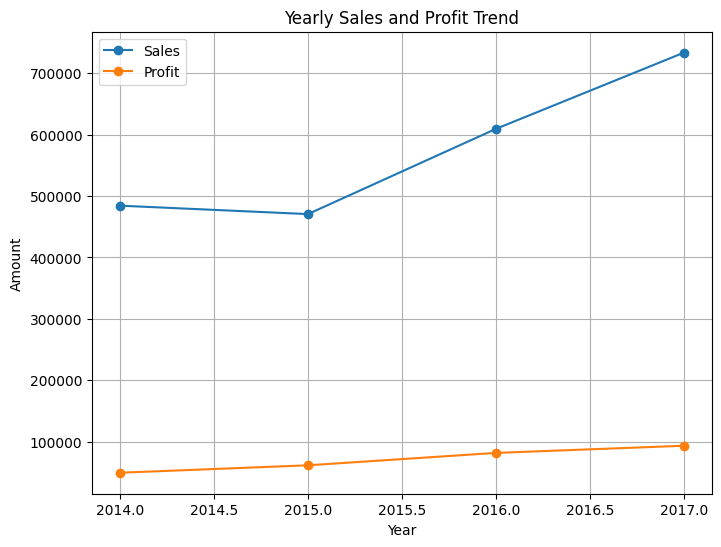

In [65]:
yearly = df.groupby("Year")[["Sales","Profit"]].sum()
plt.figure(figsize=(8,6))
plt.plot(yearly.index,yearly["Sales"],marker='o')
plt.plot(yearly.index,yearly["Profit"],marker='o')
plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(["Sales","Profit"])
plt.grid(True)
plt.show()

In [70]:
plt.savefig("yearly.png",bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

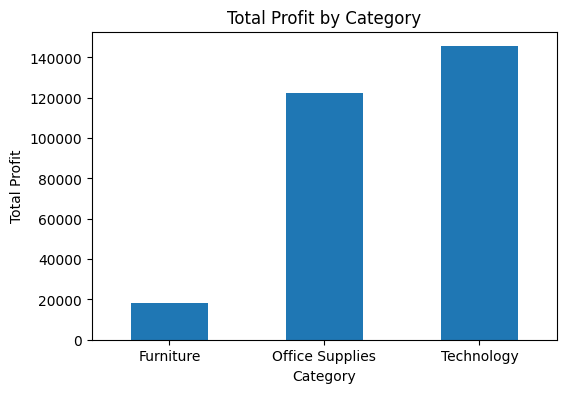

In [66]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(6,4))
category_profit.plot(kind="bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

In [71]:
plt.savefig("category.png",bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

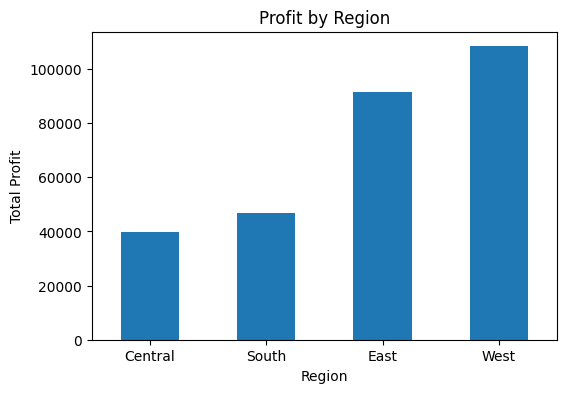

In [68]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure(figsize=(6,4))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

In [72]:
plt.savefig("regional.png",bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

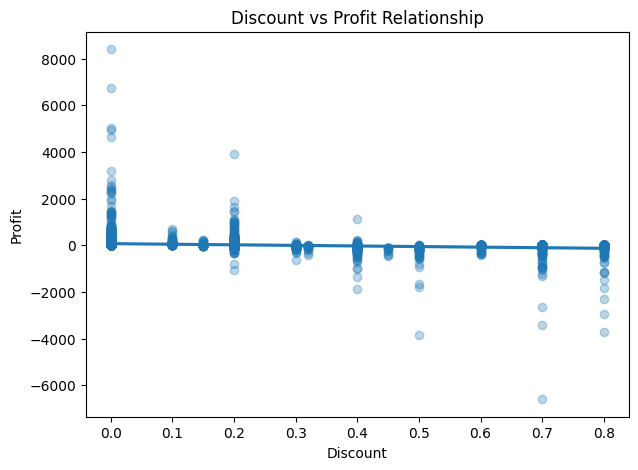

In [67]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(data=df, x="Discount", y="Profit", scatter_kws={'alpha':0.3})
plt.title("Discount vs Profit Relationship")
plt.show()

In [73]:
plt.savefig("discprof.png",bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

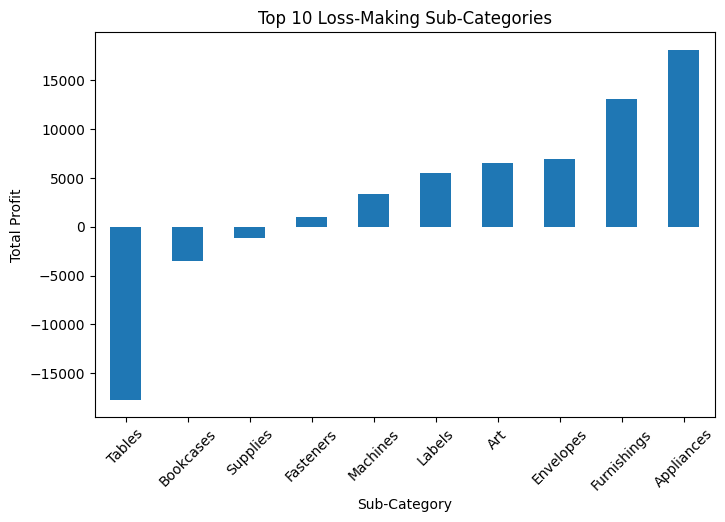

In [69]:
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values().head(10)

plt.figure(figsize=(8,5))
subcat_profit.plot(kind="bar")
plt.title("Top 10 Loss-Making Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

In [74]:
plt.savefig("subcat.png",bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [75]:
df.to_csv("cleaned_superstore.csv",index=False)